# 03. Any geometry, any analysis

Fixes nothing, asks everything: which file, which run, what it is made of,
what every face does, what to compute, where to look. The other examples pin
one case each; this is the driver they are special cases of.

| asked | answers | environment variable |
|---|---|---|
| the geometry | a `.msh` in `../Library/` (this release reads meshes only) | `PYCAFE_FILE_GEOMETRY` |
| the run | `acoustic`, `vibroacoustic` | `PYCAFE_ANSWER_ANALYSIS` |
| the fluid | `air`, `water` | `PYCAFE_ANSWER_FLUID` |
| the highest frequency | Hz; a mesh already cut says what it can carry | `PYCAFE_ANSWER_F_MAX` |
| the structure | material, thickness, support | `PYCAFE_ANSWER_MATERIAL`, `_THICKNESS`, `_SUPPORT` |
| which faces carry a condition | names, `all` or `none`; the rest are hard walls | `PYCAFE_ANSWER_BC_FACES` |
| each of those faces | `hard wall`, `soft wall`, `imposed pressure`, `impedance`, `velocity` | `PYCAFE_ANSWER_BC_<FACE>`, then `_PRESSURE_<FACE>`, `_ZETA_<FACE>`, `_VELOCITY_<FACE>` |
| a point | `none`, `monopole`, `pressure at a point` | `PYCAFE_ANSWER_POINT_SOURCE`, `_SOURCE_POINT`, `_MONOPOLE_STRENGTH`, `_POINT_PRESSURE` |
| the force | N on the structure, 0 for none | `PYCAFE_ANSWER_FORCE`, `_DRIVE_POINT` |
| the microphones | `x, y, z; x, y, z`, as many as you like | `PYCAFE_ANSWER_MICROPHONES` |
| what to compute | `modal analysis`, `direct frequency response`, `modal frequency response` | `PYCAFE_ANSWER_COMPUTE` |
| how many modes | listed and drawn in section 6 | `PYCAFE_ANSWER_NUM_MODES` |
| how large a basis | vectors the modal sweep is projected on | `PYCAFE_ANSWER_NUM_BASIS` |

**Which cells are yours.** Sections 1 to 5 are the same for everybody.
Sections 6 and 7 then split by run, one subsection each, so that the calls
your case needs are together and nothing else is in the way:

| your run | modes | response |
|---|---|---|
| acoustic | **6a** | **7a** |
| vibroacoustic | **6b** | **7b** |

The other subsection prints one line and does nothing. The response is
solved the way section 3 was answered: **directly**, one factorization per
line of the sweep, or **on a basis of modes**, one small dense system per
line. Both routes end in the same `w` and `p`, so 7c and 8 read either. Nothing is defined
here: every function called lives in `pycafe`.


---
## 1. The run

No physics stated here. The imports, and nothing else.


In [1]:
%matplotlib widget
# every figure below is a live canvas that can be turned with the mouse
# (needs ipympl); drop this line for flat pictures instead.

import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/

import numpy as np
import matplotlib.pyplot as plt

from pycafe import *          # the whole API: models, questions, solvers, plots

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("pyCAFE ready; nothing about the model is decided yet")


pyCAFE ready; nothing about the model is decided yet


---
## 2. The geometry

`ask_for_geometry()` opens a dialog on `../Library/`, filtered on `.msh`:
**this release reads gmsh meshes and nothing else**. A mesh carries its own
element sizes and its own physical group names, so loading it is the last
question about the geometry.

Which is why the dialog says how finely the files in that folder are cut, in
its own prompt and again on the console as it opens: **every mesh in
`../Library/` resolves 1500 Hz at six elements per acoustic wavelength**,

$$h = \frac{c_0}{n_\lambda\,f_{max}} = \frac{343}{6 \times 1500} = 38.1\ \text{mm},$$

so whichever file you pick, section 3 can be answered with an `f_max` up to
1500 Hz and section 5 will not refuse it. **One file is outside the rule:**
`cavity_plate_FG.msh` keeps Fahy & Gardonio's own 16 x 16 x 8 mesh, 45 mm
elements, and stops at 1270 Hz — it is the modal case of notebook 02, and its
forced twin `cavity_plate_FG_directresponse.msh` is cut past the rule instead.

Six per wavelength is a **floor**, not an accuracy target: the trilinear
element disperses as $164/n_\lambda^2$, about 4.6% there. `frequency_limits`
measures both numbers off the file below, before `f_max` is asked — 13
elements per wavelength is the 1% figure (`f_1pct`, around 690 Hz on a 38.1 mm
mesh), 6 is the floor below which pyCAFE refuses the model (`f_floor`). And
neither covers the plate: its bending wavelength is 81 mm for 1 mm aluminium
at 1500 Hz, so a coupled run up there is resolving the fluid, not the panel.


using /Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh
box_with_plate.msh: a mesh, used as it is (its physical groups already carry the roles).

MeshFile -> box_with_plate.msh

box_with_plate.msh: 5376 nodes, x 0.000 to 0.800 m,  y 0.000 to 0.600 m,  z 0.000 to 0.500 m
  volume   fluid              5376 nodes
  surface  plate               768 nodes
  surface  rigid_walls        1416 nodes
  edge     plate_clamp         108 nodes

largest fluid element 83.3 mm in air: good to ~1% up to 317 Hz, and refused above 686 Hz (6 elements per wavelength)


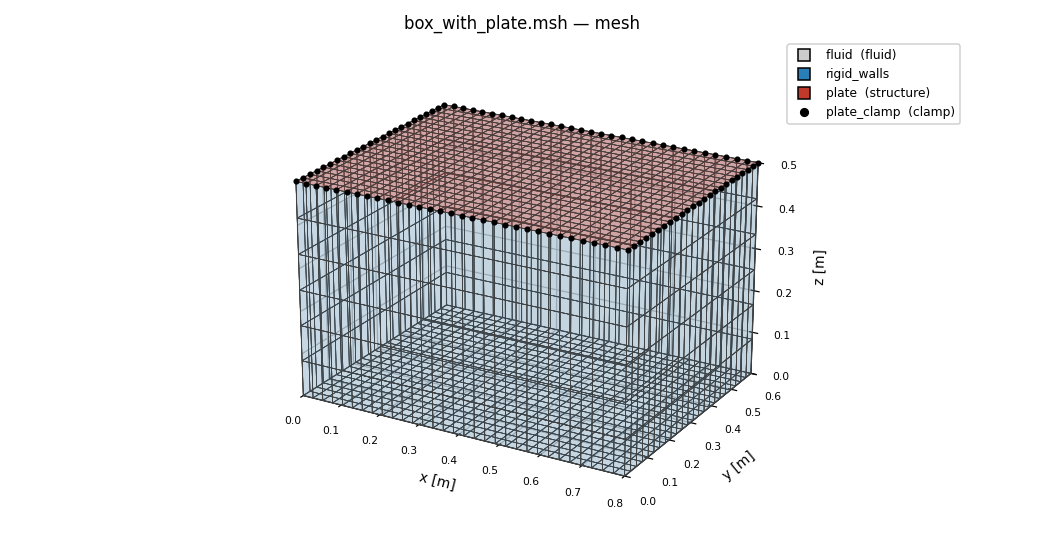

<Axes3D: title={'center': 'box_with_plate.msh — mesh'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [2]:
geometry = ask_for_geometry()      # a dialog on ../Library/, .msh only
picked = os.path.abspath(str(getattr(geometry, "path", "")))
print()
print(type(geometry).__name__, "->", os.path.basename(picked))

nodes, elements, boundaries, groups = load_mesh_with_groups(picked,
                                                            verbose=False)
surfaces = sorted(n for n, g in groups.items() if g["dim"] == 2)
volumes = sorted(n for n, g in groups.items() if g["dim"] == 3)

lo, hi = nodes.min(axis=0), nodes.max(axis=0)
print()
print(f"{os.path.basename(picked)}: {len(nodes)} nodes, "
      + ",  ".join(f"{a} {x:.3f} to {y:.3f} m"
                   for a, x, y in zip("xyz", lo, hi)))
for name, group in sorted(groups.items(), key=lambda kv: -kv[1]["dim"]):
    kind = {3: "volume", 2: "surface", 1: "edge"}.get(group["dim"], "?")
    print(f"  {kind:<8} {name:<16} {len(group['nodes']):6d} nodes")

# What this mesh can carry: its elements are already cut, so the frequency
# follows from them and not the other way round.
LIMITS = frequency_limits(picked)
if LIMITS is not None:
    print(f"\nlargest fluid element {LIMITS['h_max'] * 1e3:.1f} mm in air: "
          f"good to ~1% up to {LIMITS['f_1pct']:.0f} Hz, "
          f"and refused above {LIMITS['f_floor']:.0f} Hz "
          "(6 elements per wavelength)")

plot_mesh_3d(nodes, groups, title=f"{os.path.basename(picked)} — mesh")

# The inline backend draws a picture, not a scene. To turn the mesh by hand,
# open gmsh's own viewer; it blocks the cell until the window is closed:
# open_in_gmsh(picked)


---
## 3. What is being modelled

The run, the fluid, the highest frequency of interest, the structure when
there is one, and what to compute: the modes on their own, a sweep solved
line by line, or a sweep solved on the modes. The last one asks how many
vectors the basis carries, since a basis is not judged by the modes you
want to look at but by the ones the response needs, up to about twice the
top of the sweep. On a mesh already cut the frequency
dialog opens on the 1% limit of section 2 and says so when the answer goes
past it; on a CAD file `f_max` cuts the elements instead,
$h = c_0/(f_{max} n_\lambda)$.


In [3]:
# A mesh that carries a structural group is a coupled model unless told
# otherwise; that guess is only what the dialog opens on.
STRUCTURAL_NAMES = ("plate", "shell", "structure", "panel")
guess = ("vibroacoustic"
         if any(n in surfaces for n in STRUCTURAL_NAMES) else "acoustic")

ANALYSIS = ask_for_choice("what kind of run?", ["acoustic", "vibroacoustic"],
                          name="analysis", default=guess)
FLUID = {"air": AIR, "water": WATER}[
    ask_for_choice("what fluid fills it?", ["air", "water"],
                   name="fluid", default="air")
]
F_MAX = ask_for_number("highest frequency of interest?", unit="Hz",
                       name="f_max", minimum=1.0,
                       default=(1000.0 if LIMITS is None
                                else float(int(LIMITS["f_1pct"]))))
if LIMITS is not None and F_MAX > LIMITS["f_floor"]:
    print(f"  warning: {F_MAX:.0f} Hz is past the {LIMITS['f_floor']:.0f} Hz "
          "this mesh can carry.\n  pyCAFE will refuse it in section 5: answer "
          f"at most {LIMITS['f_floor']:.0f} Hz,\n  or {LIMITS['f_1pct']:.0f} Hz "
          "for 1% accuracy, or bring a finer mesh.")
elif LIMITS is not None and F_MAX > LIMITS["f_1pct"] + 1.0:
    print(f"  note: past {LIMITS['f_1pct']:.0f} Hz this mesh costs more than "
          "1% in frequency")

STRUCTURE = ask_for_structure() if ANALYSIS == "vibroacoustic" else None

# Three runs, the way a solver deck names them: the modes on their own, the
# sweep solved at every line, or the sweep solved on the modes. A modal
# response computes the modes anyway -- they are the basis -- so it fills
# section 6 as well.
COMPUTE = ask_for_choice("what should be computed?",
                         ["modal analysis", "direct frequency response",
                          "modal frequency response"],
                         name="compute", default="modal frequency response")
MODAL = COMPUTE in ("modal analysis", "modal frequency response")
FORCED = COMPUTE in ("direct frequency response", "modal frequency response")
METHOD = "modal" if COMPUTE == "modal frequency response" else "direct"

# Each question is asked only where its answer is used: a direct sweep is
# never asked how large a basis it wants.
N_MODES = 0
if MODAL:
    N_MODES = int(ask_for_number("how many modes?", name="num_modes",
                                 default=8.0, minimum=1.0, maximum=64.0))
frequencies, N_BASIS = None, 0
if FORCED:
    F_MIN = ask_for_number("lowest frequency of the sweep?", unit="Hz",
                           name="f_min", default=float(int(0.02 * F_MAX)) or 1.0,
                           minimum=0.0, maximum=F_MAX)
    DF = ask_for_number("frequency step of the sweep?", unit="Hz",
                        name="df", default=max(0.5, (F_MAX - F_MIN) / 400),
                        minimum=1e-3)
    frequencies = np.arange(F_MIN, F_MAX + DF, DF)

    if METHOD == "modal":
        # The modes left out of the basis still carry a static
        # flexibility, and the response misses it: the usual rule is to
        # keep every mode up to about twice the top of the sweep. Section
        # 7 says how far the basis it built actually reached.
        N_BASIS = int(ask_for_number(
            "how many modes in the basis of the sweep?", name="num_basis",
            default=float(max(40, 4 * N_MODES)), minimum=1.0, maximum=400.0))

RHO0, C0 = FLUID.rho0, FLUID.c0
print(f"\n{ANALYSIS} run in {FLUID.name}, up to {F_MAX:.0f} Hz "
      f"(lambda = {C0 / F_MAX * 1e3:.0f} mm)")
if STRUCTURE is not None:
    print(f"structure: {STRUCTURE.name}, {STRUCTURE.t * 1e3:.2f} mm, "
          f"{STRUCTURE.support}, D = {STRUCTURE.D:.3f} N m")
print(f"to compute: {COMPUTE}" + ("" if frequencies is None else
      f", sweep {F_MIN:.0f} to {F_MAX:.0f} Hz in {frequencies.size} lines"))
if METHOD == "modal" and FORCED:
    print(f"solved on {N_BASIS} modes; the rule asks for a basis reaching "
          f"{2 * F_MAX:.0f} Hz")
mine = ([("6a" if ANALYSIS == "acoustic" else "6b") + " for the modes"] if MODAL
        else [])
mine += [("7a" if ANALYSIS == "acoustic" else "7b") + " for the response"] \
    if FORCED else []
print("your subsections: " + ", ".join(mine))


analysis: vibroacoustic
fluid: air
f_max: 300 Hz
material: aluminium
thickness: 1 mm
support: clamped
compute: modal frequency response
num_modes: 6
f_min: 20 Hz
df: 10 Hz
num_basis: 60

vibroacoustic run in air, up to 300 Hz (lambda = 1143 mm)
structure: aluminium, 1.00 mm, clamped, D = 6.546 N m
to compute: modal frequency response, sweep 20 to 300 Hz in 29 lines
solved on 60 modes; the rule asks for a basis reaching 600 Hz
your subsections: 6b for the modes, 7b for the response


---
## 4. What the boundaries do, and what drives the model

Two questions, not one per face: most faces of most models are **hard
walls**, and saying so a dozen times is not a modelling decision. The first
asks which faces are something else; only those are asked about.

| answer | assembles |
|---|---|
| `hard wall` | nothing, $\partial p/\partial n = 0$ is the natural condition. **The default for every face** |
| `soft wall` | $p = 0$, those DOFs leave the problem |
| `imposed pressure` | a prescribed $p$ [Pa], partitioned out at every frequency |
| `impedance` | $\zeta = Z/(\rho_0 c_0)$; $\zeta = 1$ is the anechoic end |
| `velocity` | a prescribed outward $v_n$ [m/s], a piston |

**At a point**, one source at most: a monopole [m³/s], or a pressure held at
a node. **On the structure**: the force asked here, along the normal, on top
of the support answered in section 3. **0 N is an answer**: a coupled model
driven by a piston, a monopole or a held pressure needs no force at all.

The catalogue is the same whichever run this is.


In [4]:
STRUCTURE_GROUP = None
if ANALYSIS == "vibroacoustic" and surfaces:
    STRUCTURE_GROUP = ask_for_choice(
        "which surface is the structure?", surfaces,
        name="structure_group",
        default=next((n for n in STRUCTURAL_NAMES if n in surfaces), None),
    )

# The faces of the fluid: everything but the structure, which is not a
# boundary of the fluid but the other half of the model.
wet = [n for n in surfaces if n != STRUCTURE_GROUP]
bc, told = (ask_for_acoustic_bc(wet) if wet else (AcousticBC(), {}))

fluid_nodes0 = (np.asarray(groups[volumes[0]]["nodes"], dtype=int) - 1
                if volumes else np.arange(len(nodes)))
SOURCE_KIND, SOURCE_NODE, SOURCE_VALUE = ask_for_point_source(
    bc, nodes, candidates=fluid_nodes0,
    default_position=nodes[fluid_nodes0].mean(axis=0),
    default_is="the middle of the fluid",
)
if SOURCE_KIND != "none":
    told[SOURCE_KIND] = f"{SOURCE_VALUE:g} at node {SOURCE_NODE}"

FORCE = 0.0
if ANALYSIS == "vibroacoustic" and FORCED:
    FORCE = ask_for_number("force on the structure? (0 to drive it from the "
                           "fluid alone)", unit="N", name="force", default=1.0)
    told["force"] = (f"{FORCE:g} N normal to the structure" if FORCE
                     else "none: the fluid drives it")

# Whether anything drives the model at all. A sweep with no source comes back
# zero, which is easy to mistake for a modelling error.
DRIVEN = bool(bc.velocity or bc.monopoles or bc.pressure_constant
              or bc.point_pressure or FORCE)

for name, what in told.items():
    print(f"  {name:<18} {what}")
if not told:
    print("no face in this mesh: nothing to ask")
if FORCED and not DRIVEN:
    print("\nnothing drives this model: no velocity, no source, no held "
          "pressure, no force.\nThe sweep below will come back zero. Answer "
          "this section again with a source.")


structure_group: plate
bc_faces: none
point_source: none
force: 1 N
  rigid_walls        hard wall
  force              1 N normal to the structure


---
## 5. The model

`build_model` meshes what needs meshing, checks the size against `f_max`,
draws the mesh coloured by role and assembles. An acoustic model is
assembled with the conditions of section 4 in it; a coupled one is assembled
bare and takes them in 7b.


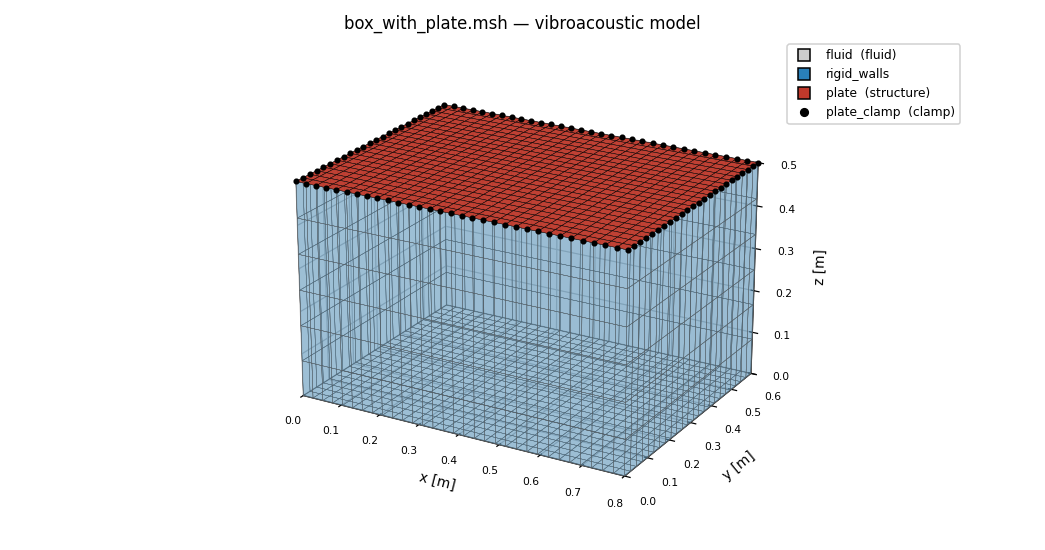

/Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh  (vibroacoustic analysis)
--------------------------------------------------------------------------------------------
  5376 nodes, 108 x Line 2, 2074 x Quadrilateral 4, 4278 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 713 faces, one fluid element behind each
  · fluid element size: 83.3 / 83.3 / 83.3 mm (min / mean / max)
  · good to ~1% up to 317 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 300 Hz: 13.7 elements per wavelength, dispersion error ~0.87%
  · selectable boundaries: rigid_walls
  => usable
domains in box_with_plate.msh (vibroacoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure   group 'plate'          <- aluminium: t = 1.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3
  support     group 'plate_clamp'    <- clamped (the mesh says which nodes are held, Structure.support say

In [5]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,
    fluid=FLUID,
    structure=STRUCTURE,
    f_max=F_MAX,
    work_dir=".",
)
try:
    model = build_model(spec, bc=bc if ANALYSIS == "acoustic" else None)
except RuntimeError:
    if LIMITS is not None and F_MAX > LIMITS["f_floor"]:
        print(f"{os.path.basename(picked)} cannot carry {F_MAX:.0f} Hz: its "
              f"elements stop at {LIMITS['f_floor']:.0f} Hz, and "
              f"{LIMITS['f_1pct']:.0f} Hz is where they still cost 1%.\n"
              "Answer section 3 again with one of those, or bring a mesh cut "
              "for the band you want.\n")
    raise

nodes = model["nodes"]
elements = model["elements"]
boundaries = model["boundaries"]
groups = model["groups"]
system = model["system"]
report = model["report"]

print(report)
print(describe_domains(report, FLUID, STRUCTURE))

fluid_nodes0 = np.asarray(groups[report.roles["fluid"]]["nodes"],
                          dtype=int) - 1
f_modal, shapes = None, None          # filled by 6a or 6b
coupled_shapes, blocks_free = None, None   # 6b only


---
## 6. Modes

Free vibration: no source, and every prescribed pressure held at zero, since
a mode has nothing to hold it anywhere else.

**6a** is the acoustic route and **6b** the coupled one. Run yours; the
other prints a line and stops.


### 6a. An acoustic run: two calls

```
acoustic_modal_system(system)          -> K, M with the held DOFs removed
solve_modal_acoustic_reduced(K, M)     -> frequencies and shapes
expand_pressure(...)                   -> the shapes back on the mesh
```


In [6]:
if ANALYSIS == "acoustic" and MODAL:
    K_h, M_h, free_nodes0 = acoustic_modal_system(system)
    f_modal, reduced = solve_modal_acoustic_reduced(K_h, M_h,
                                                    num_modes=N_MODES)
    shapes = expand_pressure(reduced, free_nodes0, nodes.shape[0])

    print(f"{f_modal.size} acoustic modes, {K_h.shape[0]} pressure DOFs "
          f"({nodes.shape[0] - K_h.shape[0]} held or outside the fluid)")
    for i, f in enumerate(f_modal):
        print(f"  mode {i + 1:2d}   {f:9.2f} Hz")
    if bc.impedance or bc.spherical_radiation:
        print("\nundamped modes: an impedance is not in K or M, so it widens "
              "the peaks\nof the sweep without moving these frequencies")


### 6b. A coupled run: two calls

```
coupled_blocks_from_bc(system, bc, ...) -> the blocks, held pressures at zero
solve_vibroacoustic_modal(system, ...)  -> frequencies and (w, p) shapes
expand_pressure(...)                    -> the acoustic half, on the mesh
```

The first mode of a sealed cavity is the 0 Hz uniform pressure, and it is a
genuine solution: nothing compresses the air.


In [7]:
if ANALYSIS == "vibroacoustic" and MODAL:
    ready = coupled_blocks_from_bc(system, bc, nodes=nodes, groups=groups,
                                   boundaries=boundaries, elements=elements)
    blocks_free = ready["blocks"]
    f_modal, coupled_shapes = solve_vibroacoustic_modal(
        system, num_modes=N_MODES, blocks=blocks_free)
    shapes = expand_pressure(coupled_shapes[blocks_free["n_s"]:],
                             blocks_free["idx_a"], nodes.shape[0])

    print(f"{f_modal.size} coupled modes, {blocks_free['n_s']} structural + "
          f"{blocks_free['n_a']} acoustic unknowns")
    for i, f in enumerate(f_modal):
        print(f"  mode {i + 1:2d}   {f:9.2f} Hz")
    if ready["held"].size:
        print(f"\n{ready['held'].size} nodes carry a prescribed pressure and "
              "are held at zero here")


6 coupled modes, 3960 structural + 5376 acoustic unknowns
  mode  1        0.00 Hz
  mode  2       32.09 Hz
  mode  3       37.48 Hz
  mode  4       45.54 Hz
  mode  5       57.44 Hz
  mode  6       57.83 Hz


### 6c. The shapes

`plot_modes` draws what the run has: an acoustic model one field per mode,
a coupled one the structure on the left and the cavity on the right, one row
per mode. The scale is diverging about white, since a mode is signed and
zero is a real place on it; each field is normalised on its own peak.


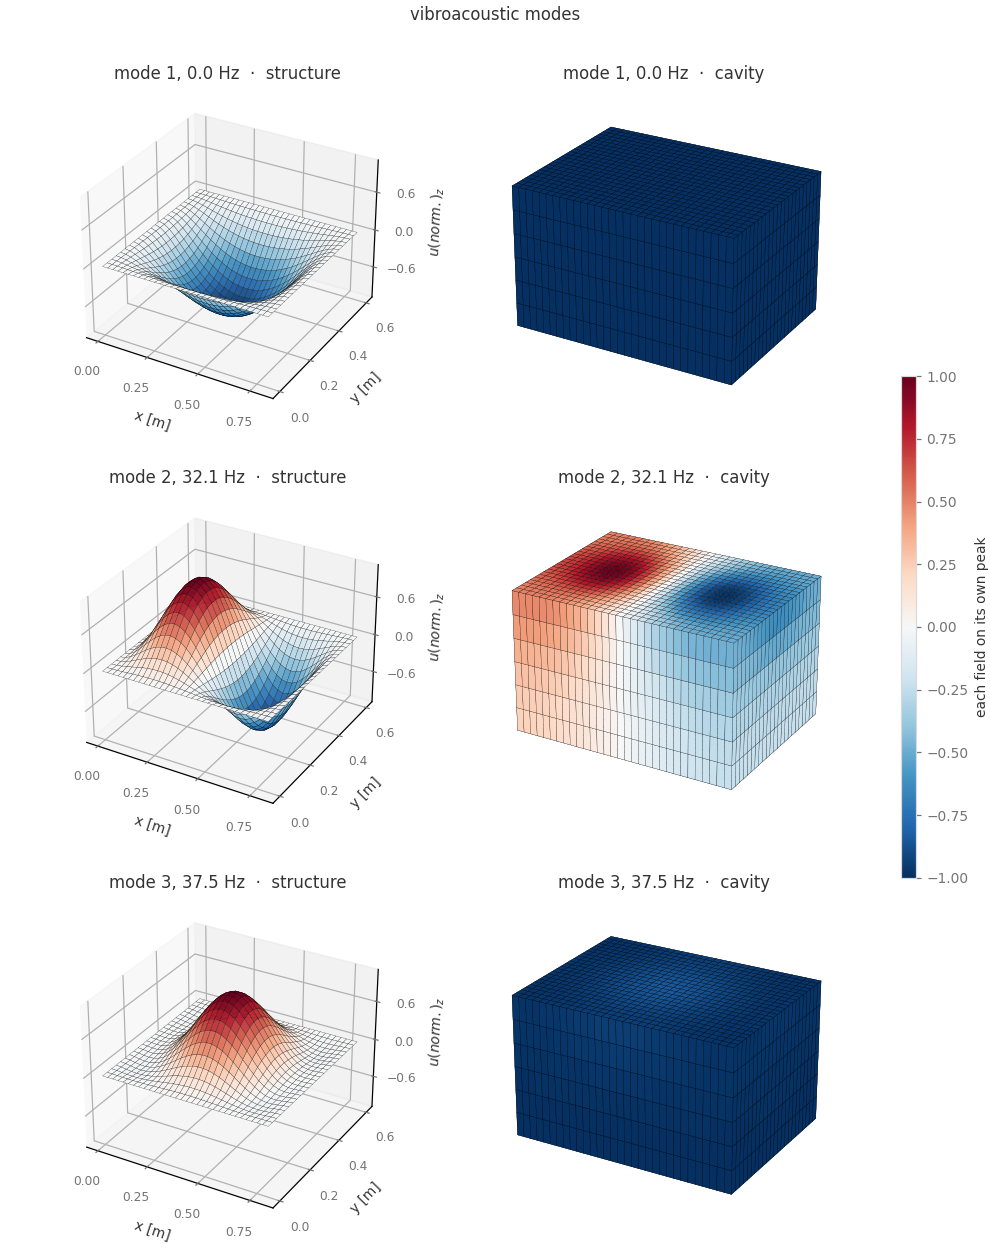

In [8]:
if f_modal is not None:
    plot_modes(model, f_modal, shapes, structure_shapes=coupled_shapes,
               blocks=blocks_free, max_modes=3 if coupled_shapes is not None
               else 6, title=f"{ANALYSIS} modes", show=True)


---
## 7. Frequency response

The microphones first, since both routes report at them: as many as the run
is worth reading at, written `x, y, z; x, y, z`. Then **7a** for an acoustic
run, **7b** for a coupled one.

Each of the two solves the sweep the way section 3 was answered. The
**direct** route factorizes the full system at every line: it takes every
condition the model carries, and it costs what it costs. The **modal**
route projects the system on a basis of modes and solves an
$m \times m$ system per line instead, which is where the time goes, at
the price of what the truncation left out.

A modal sweep cannot do everything a direct one can, and the cell says so
and solves directly instead when it meets one of these:

| in the way | why |
|---|---|
| a pressure held at a non-zero value | an essential condition, not a load: it is partitioned, not projected |
| a PML, or a radiating sphere | no projected form here |
| nothing driving the model | a basis with no load has nothing to solve |


In [9]:
MICS, response, w_drive, p_sweep = {}, {}, None, None
METHOD_USED = METHOD          # 7a or 7b says which route actually ran

if FORCED:
    # As many microphones as the run is worth reading at: the sweep costs
    # the same whether one node is read or six.
    points = ask_for_points(
        "where are the microphones?", nodes, name="microphones",
        default=nodes[fluid_nodes0].mean(axis=0),
        default_is="one in the middle of the fluid; separate several with ';'",
        candidates=fluid_nodes0,
    )
    MICS = {f"mic {k + 1}": (node0, xyz)
            for k, (node0, xyz) in enumerate(points)}


microphones 1: asked (0.2, 0.15, 0.18) -> node 2872 at (0.2065, 0.1565, 0.1667), 16.2 mm away


### 7a. An acoustic run

```
direct
  solve_acoustic_frequency_sweep(system, frequencies, ...) -> p on every node

modal
  solve_modal_frequency_sweep(K_red, M_red, frequencies, ...)
      -> p on the free DOFs, expanded onto the mesh here
```

Everything section 4 asked for is already inside `system`: the liner, the
piston, the monopole, the held pressures. The direct sweep only has to be
run. The modal one is handed the same operators — they are projected on the
basis instead of assembled into the matrix — and a liner that depends on
frequency is projected line by line, so it stays honest.


In [10]:
if ANALYSIS == "acoustic" and FORCED:
    # What the modal route cannot take, in the order it is met. Saying it
    # here and solving directly is the whole answer: the model is not
    # changed to fit the method.
    def _empty(op):
        return op is None or op.is_empty

    method, why = METHOD, None
    if METHOD == "modal":
        if np.asarray(system["pressure_nodes_red"]).size:
            why = ("a pressure is held at a value, and that is an essential "
                   "condition, not a load")
        elif (system.get("pml_red_op") is not None
              or not _empty(system.get("radiation_red_op"))):
            why = "a PML or a radiating boundary has no projected form here"
        elif (_empty(system.get("velocity_red_op"))
              and _empty(system.get("source_red_op"))):
            why = "nothing drives the model, so the basis has no load"
        if why:
            print(f"modal response not available: {why}.\n"
                  "Solved directly instead.\n")
            method = "direct"

    t0 = time.time()
    if method == "direct":
        p_sweep = solve_acoustic_frequency_sweep(
            system, frequencies, nodes=nodes, rho=RHO0,
            elements=elements, boundaries=boundaries, groups=groups,
        )
        print(f"{frequencies.size} frequencies in {time.time() - t0:.1f} s, "
              f"{system['K_red'].shape[0]} unknowns")
    else:
        m = min(N_BASIS, system["K_red"].shape[0] - 2)
        P_red, modal = solve_modal_frequency_sweep(
            system["K_red"], system["M_red"], frequencies, num_modes=m,
            C_red=system["C_red"],
            impedance_operator=system.get("C_red_op"),
            velocity_operator=system.get("velocity_red_op"),
            source_operator=system.get("source_red_op"),
            return_modal=True,
        )
        p_sweep = np.zeros((nodes.shape[0], frequencies.size), dtype=complex)
        p_sweep[system["idx_free"], :] = P_red

        f_basis = modal["omegas"].max() / (2 * np.pi)
        print(f"{frequencies.size} frequencies in {time.time() - t0:.1f} s "
              f"on {m} modes, against {system['K_red'].shape[0]} unknowns "
              "solved directly")
        print(f"the basis reaches {f_basis:.0f} Hz; the rule asks for "
              f"{2 * frequencies[-1]:.0f} Hz"
              + ("" if f_basis >= 2 * frequencies[-1]
                 else " -- answer section 3 again with more modes"))

    METHOD_USED = method
    response = {name: p_sweep[node0] for name, (node0, _) in MICS.items()}
    for name, values in response.items():
        print(f"  peak |p| at {name}: {np.abs(values).max():.3g} Pa")


### 7b. A coupled run

```
both routes
  coupled_blocks_from_bc(system, bc, ...)      -> blocks, held pressures
  structural_point_load(system, node, F, dof)  -> the force vector
  build_acoustic_load(bc, frequencies, ...)    -> the fluid load, per line

direct
  solve_vibroacoustic_frequency_sweep(...)     -> w and p over the sweep

modal
  build_coupled_modal_basis(blocks=..., num_modes=...)  -> the coupled modes
  solve_coupled_modal_frequency_sweep(basis, ...)       -> the same w and p
```

Direct, the two domains are solved together at every frequency: the matrix
is complex and unsymmetric, so each line costs its own factorization.

On the basis, the coupled modes are computed once. They are unsymmetric
too, so each right mode has a left one, and it is the left modes that
project the load. The loss factor is not in those blocks — a complex
stiffness has no eigenproblem — it enters the projected stiffness
afterwards, as $j\eta_s$ times the projected **structural** part alone.


In [11]:
if ANALYSIS == "vibroacoustic" and FORCED:
    ETA_S = ask_for_number("structural loss factor eta_s?", name="eta_s",
                           default=0.02, minimum=0.0, maximum=1.0)

    # A pressure held at a value is partitioned out of the direct system;
    # there is no such thing on a basis, so that model goes direct.
    method = METHOD
    _, held_values = prescribed_pressure(bc, boundaries=boundaries,
                                         groups=groups)
    if METHOD == "modal" and np.any(np.asarray(held_values) != 0):
        print("modal response not available: a pressure is held at a value, "
              "and that is an\nessential condition, not a load. Solved "
              "directly instead.\n")
        method = "direct"

    # eta_s belongs to the blocks on the direct path and to the projection
    # on the modal one, where the eigenproblem must stay real.
    ready = coupled_blocks_from_bc(system, bc, nodes=nodes, groups=groups,
                                   boundaries=boundaries, elements=elements,
                                   eta_s=(ETA_S if method == "direct" else 0.0))
    blocks = ready["blocks"]

    F_s, dof = np.zeros(blocks["n_s"]), None
    if FORCE:
        panel = describe_panel(nodes, groups[report.roles["structure"]]["nodes"])
        structural_nodes0 = np.unique(system["structural"]["idx_free"] // 6)
        DRIVE_NODE, drive_xyz = ask_for_point(
            f"where does the {FORCE:g} N force push the structure?", nodes,
            name="drive_point", candidates=structural_nodes0,
            default=nodes[structural_nodes0].mean(axis=0),
            default_is="the middle of the structure",
        )
        F_s, dof = structural_point_load(system, DRIVE_NODE, FORCE,
                                         panel.normal)

    F_a = build_acoustic_load(bc, frequencies, nodes=nodes, rho=RHO0,
                              idx=blocks["idx_a"], elements=elements,
                              boundaries=boundaries, groups=groups)

    t0 = time.time()
    if method == "direct":
        result = solve_vibroacoustic_frequency_sweep(
            system, frequencies, F_s=F_s, F_a=F_a, blocks=blocks,
            pressure_nodes0=ready["pressure_nodes0"],
            pressure_values=ready["pressure_values"], verbose=False)
        print(f"{frequencies.size} frequencies in {time.time() - t0:.1f} s, "
              f"{blocks['n_s'] + blocks['n_a']} unknowns")
    else:
        m = min(N_BASIS, blocks["n_s"] + blocks["n_a"] - 2)
        basis = build_coupled_modal_basis(blocks=blocks, num_modes=m)
        result = solve_coupled_modal_frequency_sweep(
            basis, frequencies, F_s=F_s, F_a=F_a, eta_s=ETA_S)

        f_basis = float(basis["freqs"].max())
        print(f"{frequencies.size} frequencies in {time.time() - t0:.1f} s "
              f"on {m} coupled modes, against "
              f"{blocks['n_s'] + blocks['n_a']} unknowns solved directly")
        print(f"the basis reaches {f_basis:.0f} Hz; the rule asks for "
              f"{2 * frequencies[-1]:.0f} Hz"
              + ("" if f_basis >= 2 * frequencies[-1]
                 else " -- answer section 3 again with more modes"))
        print(f"biorthogonality of the basis: "
              f"{basis['biorthogonality']:.1e} (0 is exact)")

    METHOD_USED = method
    p_sweep = expand_pressure(result["p"], result["idx_a"], nodes.shape[0])
    response = {name: p_sweep[node0] for name, (node0, _) in MICS.items()}
    w_drive = None if dof is None else result["w"][dof]

    for name, values in response.items():
        print(f"  peak |p| at {name}: {np.abs(values).max():.3g} Pa")
    if w_drive is not None:
        print(f"  peak |w| at the drive: {np.abs(w_drive).max():.3g} m")


eta_s: 0.02
drive_point: asked (0.2, 0.15, 0) -> node 1055 at (0.2065, 0.1565, 0.5), 500.1 mm away


29 frequencies in 0.6 s on 60 coupled modes, against 9336 unknowns solved directly
the basis reaches 465 Hz; the rule asks for 600 Hz -- answer section 3 again with more modes
biorthogonality of the basis: 1.2e-02 (0 is exact)
  peak |p| at mic 1: 14.3 Pa
  peak |w| at the drive: 0.000426 m


/Users/danielefabbri/Desktop/pycafe_new/pycafe/solver/solver_vibroacoustic_modal.py:605: RuntimeWarning: The basis reaches 465.2 Hz, below the usual 2 x f_max = 600.0 Hz rule; the response near the top of the sweep is likely truncated.
  warnings.warn(


### 7c. The response

The same two pictures whichever route ran: `w` and `p` come back on the
same unknowns, and the title says which one produced them.

One panel per quantity, never two scales on one frame; the microphones share
their panel, since they are the same quantity, and carry a legend. The grey
lines are the modes of section 6. The field is drawn at the loudest line any
microphone saw, on a single hue, **with the microphones marked on it** in the
colours of their curves.


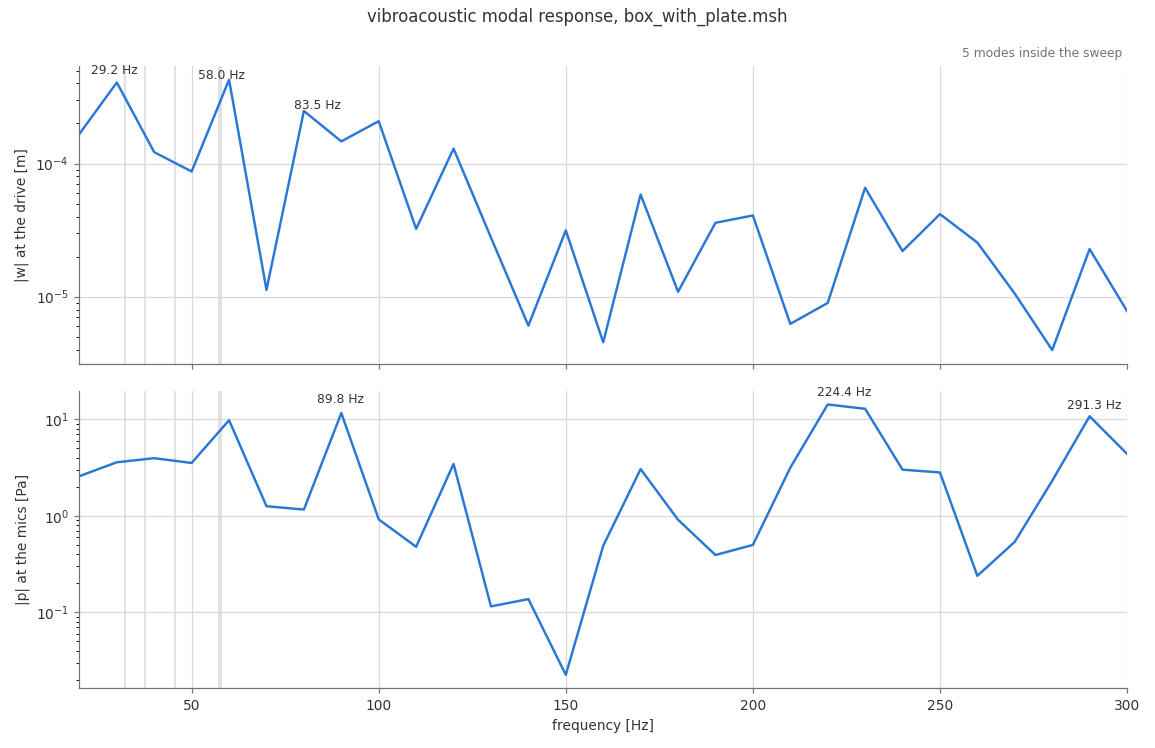

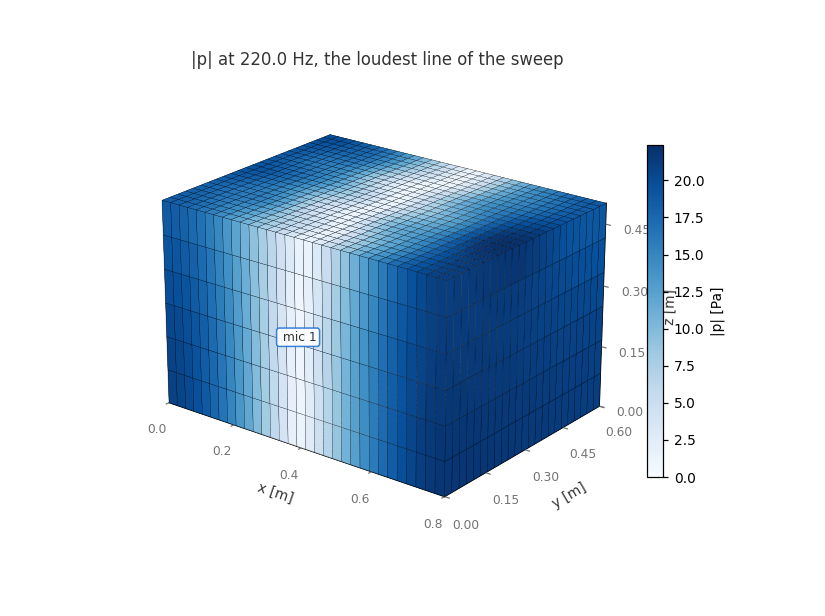

In [12]:
if response:
    signals = {"|p| at the mics [Pa]": response}
    if w_drive is not None:
        signals = {"|w| at the drive [m]": w_drive, **signals}

    plot_frf(frequencies, signals, resonances=f_modal,
             title=f"{ANALYSIS} {METHOD_USED} response, "
                   f"{os.path.basename(picked)}",
             show=True)

    # The field at the loudest line any microphone saw, with the
    # microphones on it: same colours as the curves above, in order.
    loudest = np.max([np.abs(v) for v in response.values()], axis=0)
    peak = int(np.argmax(loudest))
    plot_field(nodes, elements, p_sweep[:, peak], part="abs", show=True,
               markers={name: xyz for name, (_, xyz) in MICS.items()},
               title=f"|p| at {frequencies[peak]:.1f} Hz, the loudest line "
                     "of the sweep")


---
## 8. The response against the modes

Every peak of the sweep should sit on a mode. A mode missing from the
response is not an error: a source on a node line of that mode cannot excite
it.


In [13]:
if response and f_modal is not None:
    signals = {name.replace("mic ", "p"): values
               for name, values in response.items()}
    if w_drive is not None:
        signals["w"] = w_drive
    peaks = find_response_peaks(frequencies, signals)

    covered = f_modal[-1] if f_modal.size else 0.0
    tolerance = max(2 * DF, 0.01 * frequencies[-1])
    if covered < frequencies[-1]:
        print(f"{N_MODES} modes reach {covered:.0f} Hz, the sweep goes to "
              f"{frequencies[-1]:.0f} Hz: ask for more modes to pair the rest")

    print(f"\n{'peak [Hz]':>10} {'seen in':>14} {'mode [Hz]':>12}"
          f" {'difference':>12}")
    for f_peak, seen in peaks:
        gap = np.abs(f_modal - f_peak)
        near = f_modal[int(np.argmin(gap))] if gap.min() <= tolerance else None
        cell = f"{near:12.2f}" if near is not None else f"{'none':>12}"
        gap_cell = (f"{f_peak - near:12.2f}" if near is not None
                    else f"{'':>12}")
        print(f"{f_peak:10.2f} {'+'.join(sorted(seen)):>14} {cell}{gap_cell}")

    inside = f_modal[(f_modal >= frequencies[0]) & (f_modal <= frequencies[-1])]
    missing = missing_from_response(peaks, inside, tolerance=tolerance)
    print("\nmodes inside the sweep with no peak of their own: "
          + (", ".join(f"{f:.1f} Hz" for f in missing) if len(missing)
             else "none"))
else:
    print("both a sweep and a modal list are needed here")


6 modes reach 58 Hz, the sweep goes to 300 Hz: ask for more modes to pair the rest

 peak [Hz]        seen in    mode [Hz]   difference
     39.61           p1+w        37.48        2.14
     89.76           p1+w         none            
    118.68           p1+w         none            
    149.60              w         none            
    171.02           p1+w         none            
    195.63              w         none            
    224.36           p1+w         none            
    250.65              w         none            
    291.32           p1+w         none            

modes inside the sweep with no peak of their own: none


---
## What to change

* another geometry: pick another file in section 2, nothing below changes;
* another condition on a face, or another source: section 4;
* only modes, a sweep solved line by line, or a sweep solved on the modes:
  section 3, which asks how large the basis is when it needs one;
* a run with nobody at the keyboard: set the `PYCAFE_ANSWER_*` variables of
  the table at the top and execute the notebook as it is.
